# Анализ тональности твитов о коронавирусе
***В период пандемии COVID-19 социальные сети стали основным каналом для выражения эмоций. Анализ тональности (sentiment analysis) твитов в подобные кризисные периоды позволяет отслеживать общественные настроения и выявлять тревожные тенденции у населения.***

**Цель**: построить классификатор, который по тексту твита определяет его эмоциональную окраску (положительную или отрицательную). Для этого я использовала классические методы NLP: токенизацию, удаление стоп-слов, стемминг, векторизацию с помощью Bag-of-Words и TF-IDF, а также логистическую регрессию в качестве модели.

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import MaxAbsScaler
from sklearn.dummy import DummyClassifier
from wordcloud import WordCloud
import pickle
import warnings
warnings.filterwarnings('ignore')

In [2]:
from src.tokenizers import custom_tokenizer, custom_stem_tokenizer
from src.model_eval import evaluate_model

# Предобработка данных

In [3]:
df = pd.read_csv('data/tweets_coronavirus.csv', encoding='latin-1')
df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
1,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
2,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
3,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative
4,3804,48756,"ÃÂT: 36.319708,-82.363649",16-03-2020,As news of the regionÃÂs first confirmed COV...,Positive


In [4]:
df['Binary_sentiment'] = df['Sentiment'].apply(lambda x: 1 if x in ['Positive', 'Extremely Positive'] else 0)

In [5]:
X = df['OriginalTweet']
y = df['Binary_sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

# Векторизация текстов

## CountVectorizer

In [43]:
cv = CountVectorizer(tokenizer=custom_tokenizer)
cv.fit(X_train)
print(f'Размер словаря: {len(cv.vocabulary_)}')

Размер словаря: 45083


Рассмотрим какой-нибудь конкретный твит и определим в нем наиболее и наименее важные токены 

In [44]:
ind = 9023
tw_text = df.iloc[ind]['OriginalTweet']
tw_sentiment = df.iloc[ind]['Sentiment']
print(tw_text)
print(f'Sentiment: {tw_sentiment}')

Shop keepers taking advantage of #Coronavirus boosting prices disproportionately so the most Marginalised suffer who can't afford it #SHAMEONYOU #Wewillremember
Sentiment: Negative


In [45]:
tw_vector = cv.transform([tw_text])
feature_names = cv.get_feature_names_out()
tw_array = tw_vector.toarray()[0]
non_zero_ind = np.where(tw_array > 0)[0]

max_index = non_zero_ind[np.argmax(tw_array[non_zero_ind])]
min_index = non_zero_ind[np.argmin(tw_array[non_zero_ind])]
print(f"Наиболее важный токен: '{feature_names[max_index]}' — {tw_array[max_index]}")
print(f"Наименее важный токен: '{feature_names[min_index]}' — {tw_array[min_index]}")

Наиболее важный токен: '#coronavirus' — 1
Наименее важный токен: '#coronavirus' — 1


Cамый важный и самый неважный токены (компоненты которых в векторе максимальны/минимальны, без учета 0) совпадают, потому что каждый токен в твите встречается по одному разу (у всех токенов одинаковая частота 1), и argmax с argmin берут первый попавшийся токен. значит, **CountVectorizer плохо подходит для классификации**, так как определяет важность только по частоте в одном твите

## TfidfVectorizer

In [46]:
tfidf = TfidfVectorizer(tokenizer=custom_tokenizer)
tfidf.fit(X_train)

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",<function cus...002AA0169E140>
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyz

In [47]:
tw_vector_tfidf = tfidf.transform([tw_text])
feature_names_tfidf = tfidf.get_feature_names_out()
tweet_array_tfidf = tw_vector_tfidf.toarray()[0]
non_zero_tfidf = np.where(tweet_array_tfidf > 0)[0]
max_idx_tfidf = non_zero_tfidf[np.argmax(tweet_array_tfidf[non_zero_tfidf])]
min_idx_tfidf = non_zero_tfidf[np.argmin(tweet_array_tfidf[non_zero_tfidf])]
    
print(f"Наиболее важный токен: '{feature_names_tfidf[max_idx_tfidf]}' — {tweet_array_tfidf[max_idx_tfidf]:.4f}")
print(f"Наименее важный токен: '{feature_names_tfidf[min_idx_tfidf]}' — {tweet_array_tfidf[min_idx_tfidf]:.4f}")

Наиболее важный токен: '#wewillremember' — 0.3760
Наименее важный токен: '#coronavirus' — 0.0720


\#wewillremember - редкий хештег во всем корпусе, поэтому получил высокий вес (0,376), а #coronavirus - очень частый хештег среди всех твитов, получил низкий вес (0,072). Можем сделать вывод, что **TF-IDF лучше подходит для классификации**, потому что выделяет редкие информативные токены и игнорирует общие слова

Проверим, как работает TfidfVectorizer, на каком-нибудь положительном твите

In [48]:
pos_ind = 43
pos_tweet = df.iloc[pos_ind]['OriginalTweet']
print(pos_tweet)
print(f'Sentiment: {df.iloc[pos_ind]['Sentiment']}')

Morning everyone have a great and safe day. ??? #coronavirus #StopPanicBuying #BeKind #mufc #MUFC_Family
Sentiment: Extremely Positive


In [49]:
tw_vector_tfidf = tfidf.transform([pos_tweet])
feature_names_tfidf = tfidf.get_feature_names_out()
tweet_array_tfidf = tw_vector_tfidf.toarray()[0]
non_zero_tfidf = np.where(tweet_array_tfidf > 0)[0]
max_idx_tfidf = non_zero_tfidf[np.argmax(tweet_array_tfidf[non_zero_tfidf])]
min_idx_tfidf = non_zero_tfidf[np.argmin(tweet_array_tfidf[non_zero_tfidf])]
    
print(f"Наиболее важный токен: '{feature_names_tfidf[max_idx_tfidf]}' — {tweet_array_tfidf[max_idx_tfidf]:.4f}")
print(f"Наименее важный токен: '{feature_names_tfidf[min_idx_tfidf]}' — {tweet_array_tfidf[min_idx_tfidf]:.4f}")

Наиболее важный токен: '#bekind' — 0.5091
Наименее важный токен: '#coronavirus' — 0.1346


На примере нашего резко положительного твита TfidfVectorizer хорошо выделяет важные токены. #bekind - редкий хештег, несет прямую положительную эмоциональную окраску, tfidf правильно определил ему большой вес (0.5)

# Обучение моделей без стемминга

## Наивный классификатор
До обучения сложных моделей оценим, какую точность даёт самый простой подход — предсказание самого частого класса.

In [50]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
dummy_accuracy = accuracy_score(y_test, y_pred_dummy)
print(f"Accuracy DummyClassifier: {dummy_accuracy:.4f}")

Accuracy DummyClassifier: 0.5396


## Логистическая регрессия

Сравним CountVectorizer и TfidfVectorizer, обучив логистическую регрессию на векторах из обоих векторайзеров

In [51]:
X_train_cv = cv.transform(X_train)
X_test_cv = cv.transform(X_test)

X_train_tfidf = tfidf.transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [52]:
results = []
metrics_cv = evaluate_model(LogisticRegression(max_iter=1000, random_state=0), X_train_cv, y_train, X_test_cv, y_test, model_name='CV')
metrics_tfidf = evaluate_model(LogisticRegression(max_iter=1000, random_state=0), X_train_tfidf, y_train, X_test_tfidf, y_test, model_name='Tfidf')
results.append(metrics_cv)
results.append(metrics_tfidf)

In [53]:
res_df = pd.DataFrame(results).round(4)
res_df

,Model,Train Accuracy,Test Accuracy,Test ROC-AUC,Overfit
0,CV,0.9837,0.8731,0.9402,0.1106
1,Tfidf,0.9251,0.8513,0.9292,0.0738


Обе модели показали высокие результаты на тесте (accuracy > 85%). CV показал более высокую точность на тесте, но при этом большое переобучение (разрыв между train и test 11%), а TF-IDF показал меньшее переобучение, но ниже точность на тесте. То есть TF-IDF будет лучше работать на новых данных

# Улучшение качества моделей

## Стемминг

Используем модифицированную версию собственного токенайзера, в которую входит стемминг

In [54]:
cv_stem = CountVectorizer(tokenizer=custom_stem_tokenizer)
X_train_cv_stem = cv_stem.fit_transform(X_train)

print(f'Размер словаря после стемминга: {len(cv_stem.vocabulary_)}')

Размер словаря после стемминга: 36369


Размер словаря уменьшился с 45083 до 36369, потому что при стемминге у слов отбрасываются суффиксы и окончания, что помогает сократить количество уникальных токенов без потери смысла

In [55]:
X_test_cv_stem = cv_stem.transform(X_test)

tfidf_stem = TfidfVectorizer(tokenizer=custom_stem_tokenizer)
X_train_tfidf_stem = tfidf_stem.fit_transform(X_train)
X_test_tfidf_stem = tfidf_stem.transform(X_test)

In [56]:
metrics_cv_stem = evaluate_model(LogisticRegression(max_iter=1000, random_state=0), X_train_cv_stem, y_train, X_test_cv_stem, y_test, model_name='CV stemming')
metrics_tfidf_stem = evaluate_model(LogisticRegression(max_iter=1000, random_state=0), X_train_tfidf_stem, y_train, X_test_tfidf_stem, y_test, model_name='Tfidf stemming')
results.append(metrics_cv_stem)
results.append(metrics_tfidf_stem)

In [57]:
res_df = pd.DataFrame(results).round(4)
res_df.sort_values('Model')

,Model,Train Accuracy,Test Accuracy,Test ROC-AUC,Overfit
0,CV,0.9837,0.8731,0.9402,0.1106
2,CV stemming,0.9707,0.8708,0.9376,0.0999
1,Tfidf,0.9251,0.8513,0.9292,0.0738
3,Tfidf stemming,0.9170,0.8599,0.9315,0.0571


Для оценки качества моделей были использованы `Accuracy` (долю правильных ответов) и `ROC-AUC` (способность модели различать классы). F1-Score не рассматривался отдельно, так как классы сбалансированы (54% / 46%), и в таких условиях F1 практически совпадает с Accuracy, не добавляя новой информации.

- Лучшей моделью по обоим метрикам на тесте оказался **CountVectorizer без стемминга** (accuracy = 0.87, ROC-AUC = 0.94). Однако она показывает наибольшее переобучение (разрыв Train-Test на Accuracy = 11%).
- Модель с лучшим балансом качества и обобщения - это **TF-IDF со стеммингом** (accuracy 0.86, ROC-AUC 0.93, разрыв Train-Test всего 5.7%). Модель хорошо работает на новых данных и меньше всего подвержена переобучению, имеет смысл оптимизировать ее дальше

## Биграммы

In [32]:
tfidf2_stem = TfidfVectorizer(tokenizer=custom_stem_tokenizer, ngram_range=(1,2))
X_train_tfidf2_stem = tfidf2_stem.fit_transform(X_train)
X_test_tfidf2_stem = tfidf2_stem.transform(X_test)

In [33]:
results_bi = []
metrics_tf_bi = evaluate_model(LogisticRegression(max_iter=1000, random_state=0), X_train_tfidf2_stem, y_train, X_test_tfidf2_stem, y_test, model_name='Tfidf stem bi')
results_bi.append(metrics_tf_bi)

In [36]:
res_bi_df = pd.concat([res_df[res_df['Model'] == 'Tfidf stemming'], pd.DataFrame(results_bi)])
res_bi_df.round(4)

,Model,Train Accuracy,Test Accuracy,Test ROC-AUC,Overfit
3,Tfidf stemming,0.9170,0.8599,0.9315,0.0571
0,Tfidf stem bi,0.9475,0.8425,0.9148,0.1050


Использование биграммов на лучшей модели (TF-IDF со стеммингом) **ухудшило качество предсказания**:
- Accuracy и ROC-AUC на тесте понизились, по сравнению с моделью, обученной на униграммах,
- Переобучение выросло в два раза (разрыв Train-Test вырос с 5% до 10%).

Многие биграммы встречаются редко, что создает шум, на который модель и переобучается. В нашем случае лучше ограничиться униграммами, так как использование больших N-граммов приведет только к более сильному переобучению.

## Работа с частотами

Чтобы улучшить нашу модель попробуем настроить гиперпараметры, отвечающие за частоту документа:
- `min_df` - минимальная частота документа (удаляет редкие слова),
- `max_df` - максимальная частота документа (удаляет слишком частые слова)

In [72]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(tokenizer=custom_stem_tokenizer)),
    ('logreg', LogisticRegression(max_iter=1000, random_state=0))
])

In [73]:
param_grid = {
    'tfidf__min_df': [1, 3, 5, 10],
    'tfidf__max_df': [0.5, 0.7, 0.9, 1]
    }
grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy')
grid.fit(X_train, y_train)
print(f'Лучшие параметры: {grid.best_params_}')
print(f'Лучший Accuracy на кросс-валидации: {grid.best_score_:.4f}')

Лучшие параметры: {'tfidf__max_df': 0.5, 'tfidf__min_df': 5}
Лучший Accuracy на кросс-валидации: 0.8436


In [77]:
tf = TfidfVectorizer(tokenizer=custom_stem_tokenizer, min_df=5, max_df=0.5).fit(X_train)
print(f'Размер нового словаря: {len(tf.vocabulary_)}')

Размер нового словаря: 6121


- `min_df=5`: удалены токены, встречающиеся менее чем в 5 твитах. Это отсеяло редкие опечатки, уникальные ссылки и имена, которые создавали шум.
- `max_df=0.5`: удалены токены, встречающиеся более чем в 50% твитов. Это удалило слишком общие слова, которые не несли тональности и создавали переобучение.

**Результат:** Размер словаря сократился с 36369 до 6121 токенов. Это значит, что большинство уникальных токенов в твитах встречаются лишь 1–2 раза и являются шумом (опечатки, уникальные ссылки, имена)

In [6]:
tf_tuned = TfidfVectorizer(tokenizer=custom_stem_tokenizer, min_df=5, max_df=0.5)
X_train_tuned = tf_tuned.fit_transform(X_train)
X_test_tuned = tf_tuned.transform(X_test)

In [59]:
lr = LogisticRegression(max_iter=1000, random_state=0)
lr.fit(X_train_tuned, y_train)
metrics_tf = evaluate_model(lr, X_train_tuned, y_train, X_test_tuned, y_test, model_name='Tfidf stem tuned', fitted=True)

In [60]:
res_tuned = []
res_tuned.append(metrics_tf)
tuned_df = pd.concat([res_df[res_df['Model'] == 'Tfidf stemming'], pd.DataFrame(res_tuned)])
tuned_df.round(4)

,Model,Train Accuracy,Test Accuracy,Test ROC-AUC,Overfit
3,Tfidf stemming,0.9170,0.8599,0.9315,0.0571
0,Tfidf stem tuned,0.9052,0.8641,0.9340,0.0411


Подбор гиперпараметров помог повысить качество предсказаний:
- Accuracy и ROC-AUC на тесте немного выросли,
- Уменьшилось переобучение, так как удаление редких и частых токенов заставило модель фокусироваться на действительно значимых повторяющихся паттернах.

## Масштабирование

Используем `MaxAbsScaler` для масштабирования данных, так как он лучше всего работает с разреженными матрицами

In [ ]:
scaler = MaxAbsScaler() 
X_train_scaled = scaler.fit_transform(X_train_tuned)
X_test_scaled = scaler.transform(X_test_tuned)

lr_scaled = LogisticRegression(max_iter=1000, random_state=0)
metrics_sc = evaluate_model(lr_scaled, X_train_scaled, y_train, X_test_scaled, y_test, model_name='Tfidf stem tuned scaled')

In [67]:
res_scaled = []
res_scaled.append(metrics_sc)
scaled_df = pd.concat([tuned_df, pd.DataFrame(res_scaled)], ignore_index=True)
scaled_df.style.highlight_max(subset=['Test Accuracy'], color='green')

,Model,Train Accuracy,Test Accuracy,Test ROC-AUC,Overfit
0,Tfidf stemming,0.917000,0.859900,0.931500,0.057100
1,Tfidf stem tuned,0.905169,0.864062,0.933977,0.041107
2,Tfidf stem tuned scaled,0.931482,0.863464,0.936497,0.068018


`MaxAbsScaler` дал небольшой прирост ROC‑AUC (0.9365 против 0.9340), но при этом **ухудшил обобщение** (Overfit вырос до 0.068) и немного снизил Accuracy на тесте.

Так произошло из-за того, что `TfidfVectorizer` сам нормализует признаки (длина вектора каждого документа = 1 при norm='l2', который стоит по дефолту). Дополнительное масштабирование не добавляет новой информации, а лишь меняет масштаб, что не влияет на линейные модели с правильной регуляризацией. 

Поэтому самой лучшей моделью остался **TF-IDF со стеммингом и подобранными гиперпараметрами**

# Настройка классификатора

После фиксации лучших параметров векторайзера (`min_df=5`, `max_df=0.5`) попробуем оптимизировать сам классификатор

In [ ]:
param_grid_lr = [
    {'penalty': ['l1'],
    'solver': ['saga', 'liblinear'],
    'C': [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]},
    
    {'penalty': ['l2'],
     'solver': ['lbfgs', 'saga'],
    'C': [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]}
]

In [8]:
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=0), param_grid_lr, cv=4, scoring='accuracy', n_jobs=-1, verbose=1)
grid_lr.fit(X_train_tuned, y_train)
print(f"Лучшие параметры для классификатора: {grid_lr.best_params_}")
print(f"Лучший Accuracy на кросс-валидации: {grid_lr.best_score_:.4f}")

Fitting 4 folds for each of 28 candidates, totalling 112 fits
Лучшие параметры для классификатора: {'C': 2.0, 'penalty': 'l1', 'solver': 'liblinear'}
Лучший Accuracy на кросс-валидации: 0.8771


In [ ]:
best_lr = grid_lr.best_estimator_
final = []
final.append(evaluate_model(best_lr, X_train_tuned, y_train, X_test_tuned, y_test, 'Best params'))
final_df = pd.concat([tuned_df, pd.DataFrame(final)])
final_df.round(4)

,Model,Train Accuracy,Test Accuracy,Test ROC-AUC,Overfit
3,Tfidf stemming,0.9170,0.8599,0.9315,0.0571
0,Tfidf stem tuned,0.9052,0.8641,0.9340,0.0411
0,Best params,0.9231,0.8834,0.9469,0.0397


По результатам GridSearchCV больший прирост в Accuracy на кроссвалидации дала **L1-регуляризация** (С=2 и solver='liblinear'), которая автоматически отбирает признаки и снижает переобучение.

После оценки новой модели на тестовой выборке можно заметить, что действительно **уменьшилось переобучение**, а также **выросли обе метрики** на тестовой выборке

In [27]:
best_model = LogisticRegression(max_iter=1000, random_state=0, penalty='l1', C=2.0, solver='liblinear')
best_model.fit(X_train_tuned, y_train)
y_train_pred = best_model.predict(X_train_tuned)
y_test_pred = best_model.predict(X_test_tuned)
y_test_proba = best_model.predict_proba(X_test_tuned)[:, 1]

In [63]:
with open('models/best_model.pkl', 'wb') as f:
    pickle.dump((tf_tuned, best_model), f)

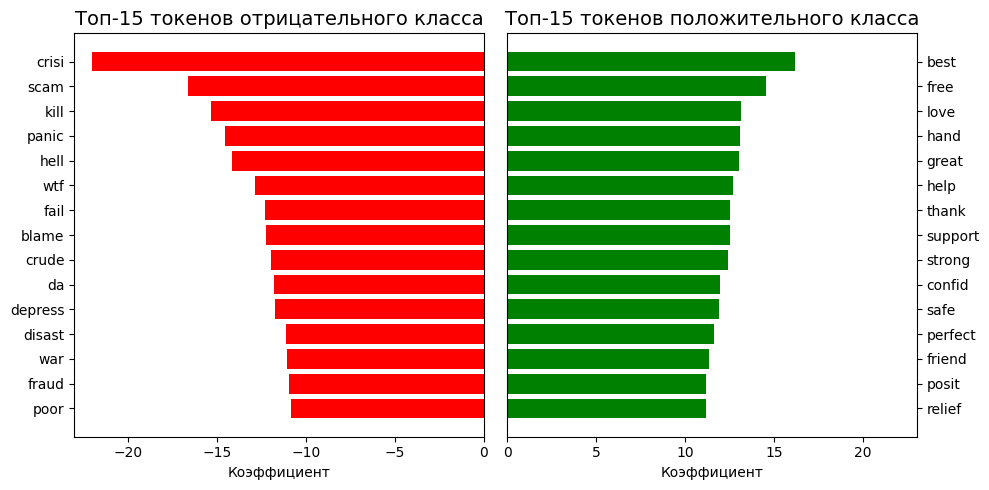

In [20]:
feature_names = tf_tuned.get_feature_names_out()
coefficients = best_model.coef_[0]

top_neg_idx = np.argsort(coefficients)[:15]
top_neg = [(feature_names[i], coefficients[i]) for i in top_neg_idx]
tokens_neg = [t[0] for t in top_neg]
weights_neg = [t[1] for t in top_neg]

top_pos_idx = np.argsort(coefficients)[-15:][::-1]
top_pos = [(feature_names[i], coefficients[i]) for i in top_pos_idx]
tokens_pos = [t[0] for t in top_pos]
weights_pos = [t[1] for t in top_pos]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
most_imp = np.max(np.abs(weights_neg + weights_pos))
lim = most_imp+1

axes[0].barh(tokens_neg, weights_neg, color='red')
axes[0].set_xlim(-lim, 0)
axes[0].set_title('Топ-15 токенов отрицательного класса', fontsize=14)
axes[0].set_xlabel('Коэффициент')
axes[0].invert_yaxis()

axes[1].barh(tokens_pos, weights_pos, color='green')
axes[1].set_xlim(0, lim)
axes[1].set_title('Топ-15 токенов положительного класса', fontsize=14)
axes[1].set_xlabel('Коэффициент')
axes[1].invert_yaxis()
axes[1].yaxis.tick_right()

plt.tight_layout()
plt.show()

In [60]:
for idx, tweet in enumerate(X_train):
    tokens = custom_stem_tokenizer(tweet)
    if 'da' in tokens:
        print(idx, tweet)

5095 Thanks Costco! You da best! Fuck all those ass hats that bought everything only to resale at ridiculous prices. #coronavirus #COVID19 #CoronaVirusChallenge #SocialDistanacing #StaySafeStayHome #COVID https://t.co/vq6ahKQlkt
9292 The ALIENS have sent the #Coronavirus to Earth for a Human Slow Death @CNBCJulianna @CNBCJou this shit is #Crazy. Grocery Store workers are dying from da RONA now. I HOPE this is Fake news as my Favorito American President states. "Only CNN would ask a question like that" #Idiot
9817 @Naveen_Odisha @SarangiSudhansu @narendramodi @PMOIndia sir I m a retail shop worker. I m facing lots of challenges 2 reach 2 da store every day.Neither u r supporting nor taking a strong call to close the retail shops. Why ?? We don't have family ? We ar
10440 REMINDER IT S ILLEGAL for a business to increase prices for essential goods services more than 10 during a declared state of emergency REPORT suspected to the DA s Consumer Protection Unit 619 531 3507 DETAILS
15407 Na,

In [62]:
da_pos = 0
da_neg = 0
for idx, tweet in enumerate(X_train):
    tokens = custom_stem_tokenizer(tweet)
    if 'da' in tokens:
        if y_train.iloc[idx] == 1:
            da_pos += 1
        else:
            da_neg += 1

print(f"'da' в позитивных твитах: {da_pos}")
print(f"'da' в негативных твитах: {da_neg}")

'da' в позитивных твитах: 1
'da' в негативных твитах: 8


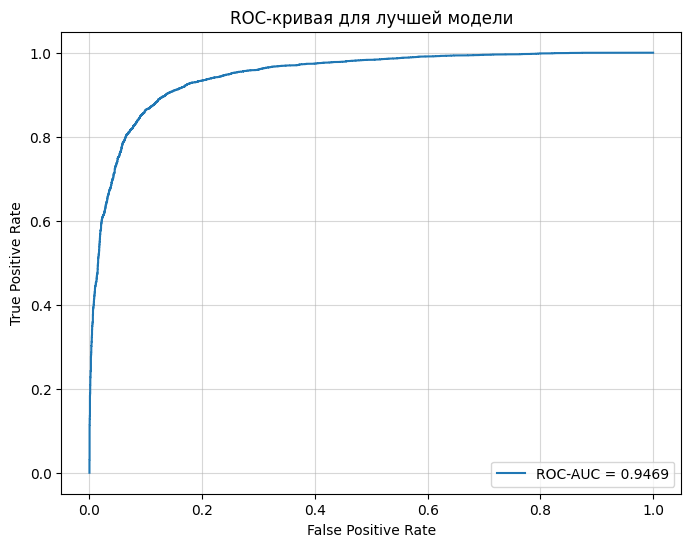

In [32]:
fpr, tpr, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_test, y_test_proba):.4f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая для лучшей модели')
plt.legend(loc='lower right')
plt.grid(alpha=0.5)
plt.show()

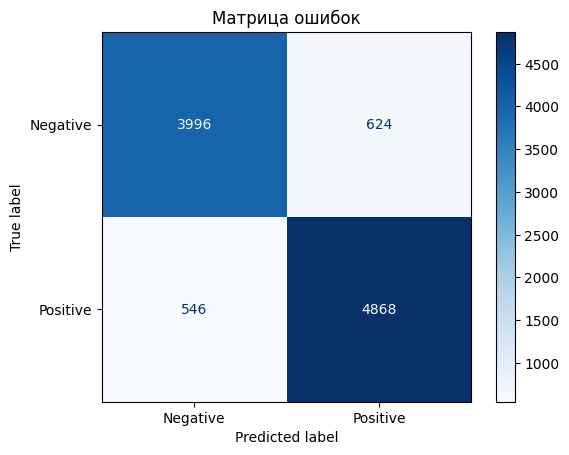

In [59]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('Матрица ошибок')
plt.show()

In [39]:
print(classification_report(y_test, y_test_pred, target_names=['Positive', 'Negative']))

              precision    recall  f1-score   support

    Positive       0.88      0.86      0.87      4620
    Negative       0.89      0.90      0.89      5414

    accuracy                           0.88     10034
   macro avg       0.88      0.88      0.88     10034
weighted avg       0.88      0.88      0.88     10034



In [55]:
train_indices = X_train.index
train_df = df.loc[train_indices]

positive_tweets = train_df[train_df['Binary_sentiment'] == 1]['OriginalTweet']
negative_tweets = train_df[train_df['Binary_sentiment'] == 0]['OriginalTweet']

def get_cleaned_text(tweets_series):
    all_tokens = []
    for tweet in tweets_series:
        tokens = custom_tokenizer(tweet) 
        all_tokens.extend(tokens)
    return ' '.join(all_tokens)

positive_text = get_cleaned_text(positive_tweets)
negative_text = get_cleaned_text(negative_tweets)

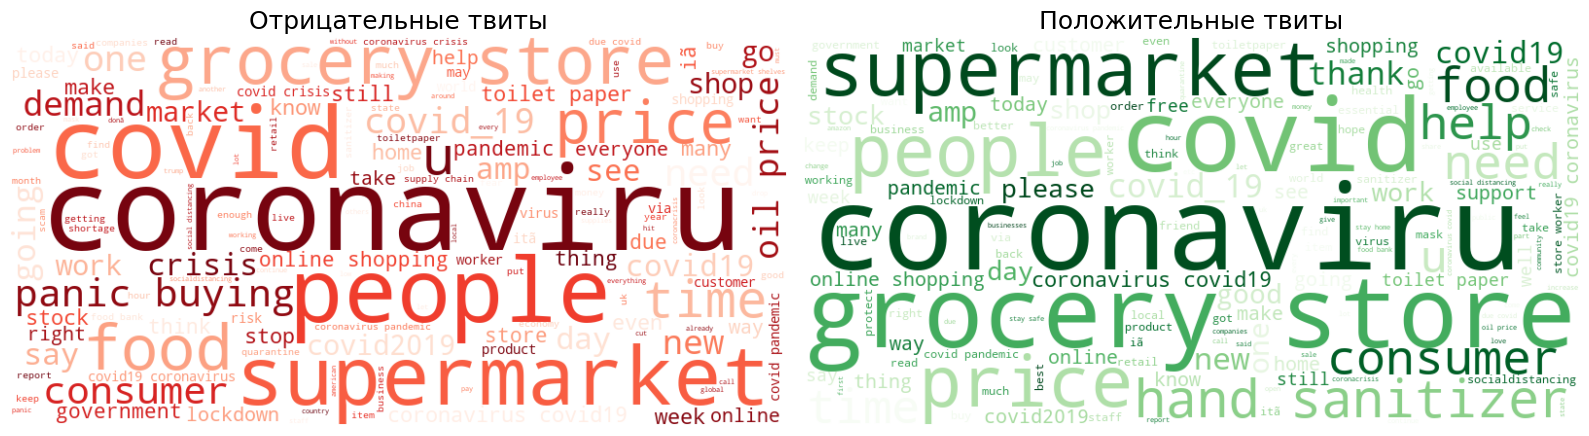

In [56]:
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', max_words=150, 
                          colormap='Greens', random_state=0).generate(positive_text)

wordcloud_neg = WordCloud(width=800, height=400, background_color='white', max_words=150,
                          colormap='Reds', random_state=0).generate(negative_text)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
ax2.imshow(wordcloud_pos, interpolation='bilinear')
ax2.set_title('Положительные твиты', fontsize=18)
ax2.axis('off')

ax1.imshow(wordcloud_neg, interpolation='bilinear')
ax1.set_title('Отрицательные твиты', fontsize=18)
ax1.axis('off')

plt.tight_layout()
plt.show()